In [248]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np

In [249]:
df=pd.read_csv('/content/job_fit_1000.csv')

In [250]:
df.head()

,id,required_skills,candidate_skills,degree,years_experience,overlap,fit,probability,missing_skills
0,FIT0000,"Docker, Excel, Linux, R, REST, TensorFlow","AWS, Airflow, ETL, Hadoop, TypeScript",Masters,0.9,0.0,0.0,0.237,"Docker, Excel, Linux, R, REST, TensorFlow"
1,FIT0001,"CI/CD, Docker, Flask, JavaScript, Kubernetes, ...","Kubernetes, NumPy, Python, Spark",Masters,1.9,2.0,1.0,0.467,"CI/CD, Docker, Flask, JavaScript, Node.js, React"
2,FIT0002,"Django, Node.js, PyTorch, React, SQL, TensorFlow","Django, Git, Kubernetes, Node.js, NumPy, React...",Masters,2.5,3.0,1.0,0.585,"PyTorch, SQL, TensorFlow"
3,FIT0003,"Docker, ETL, Flask, Python, REST, TensorFlow, ...","AWS, Excel, Hadoop, PyTorch, R",Bachelors,2.7,0.0,0.0,0.231,"Docker, ETL, Flask, Python, REST, TensorFlow, ..."
4,FIT0004,"Airflow, Docker, Kubernetes, Pandas, R","Docker, GraphQL, PyTorch, REST, SQL",Bachelors,4.9,1.0,1.0,0.397,"Airflow, Kubernetes, Pandas, R"


In [251]:
df.shape

(1000, 9)

In [252]:
df.describe()

,years_experience,overlap,fit,probability
count,985.000000,980.000000,979.000000,984.000000
mean,3.541015,1.384694,0.401430,0.417496
std,1.944108,1.040532,0.490438,0.125249
min,0.000000,0.000000,0.000000,0.150000
25%,2.100000,1.000000,0.000000,0.328000
50%,3.600000,1.000000,0.000000,0.409000
75%,4.900000,2.000000,1.000000,0.498000
max,9.900000,6.000000,1.000000,0.888000


# Data cleaning


In [253]:
df.isnull().sum()


,0
id,13
required_skills,26
candidate_skills,18
degree,18
years_experience,15
overlap,20
fit,21
probability,16
missing_skills,21


In [254]:
df.duplicated().sum()

np.int64(0)

In [255]:
def to_lowercase(text):
    if isinstance(text, str):
        return text.lower()
    return text
# Identifier les colonnes catégorielles / texte
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(categorical_cols)

['id', 'required_skills', 'candidate_skills', 'degree', 'missing_skills']


In [256]:
for col in categorical_cols:
    df[col] = df[col].apply(to_lowercase)

# Vérifier le résultat
df.head()

,id,required_skills,candidate_skills,degree,years_experience,overlap,fit,probability,missing_skills
0,fit0000,"docker, excel, linux, r, rest, tensorflow","aws, airflow, etl, hadoop, typescript",masters,0.9,0.0,0.0,0.237,"docker, excel, linux, r, rest, tensorflow"
1,fit0001,"ci/cd, docker, flask, javascript, kubernetes, ...","kubernetes, numpy, python, spark",masters,1.9,2.0,1.0,0.467,"ci/cd, docker, flask, javascript, node.js, react"
2,fit0002,"django, node.js, pytorch, react, sql, tensorflow","django, git, kubernetes, node.js, numpy, react...",masters,2.5,3.0,1.0,0.585,"pytorch, sql, tensorflow"
3,fit0003,"docker, etl, flask, python, rest, tensorflow, ...","aws, excel, hadoop, pytorch, r",bachelors,2.7,0.0,0.0,0.231,"docker, etl, flask, python, rest, tensorflow, ..."
4,fit0004,"airflow, docker, kubernetes, pandas, r","docker, graphql, pytorch, rest, sql",bachelors,4.9,1.0,1.0,0.397,"airflow, kubernetes, pandas, r"


In [257]:
df.isnull().sum()

,0
id,13
required_skills,26
candidate_skills,18
degree,18
years_experience,15
overlap,20
fit,21
probability,16
missing_skills,21


In [258]:
df = df.drop(columns=["id"])


In [201]:
df.columns

Index(['required_skills', 'candidate_skills', 'degree', 'years_experience',
       'overlap', 'fit', 'probability', 'missing_skills'],
      dtype='object')

In [259]:
df['overlap'].unique()

array([ 0.,  2.,  3.,  1., nan,  4.,  5.,  6.])

In [260]:
cols_to_check = [
   "required_skills", "candidate_skills", "degree",
    "years_experience",  "fit", "probability", "missing_skills"
]

# Supprimer les lignes avec NaN dans au moins une de ces colonnes
df = df.dropna(subset=cols_to_check)

# Vérifier qu'il n'y a plus de valeurs manquantes
print(df.isnull().sum())


required_skills      0
candidate_skills     0
degree               0
years_experience     0
overlap             13
fit                  0
probability          0
missing_skills       0
dtype: int64


In [261]:
def compute_overlap(req, cand):
    if pd.isna(req) or pd.isna(cand):
        return 0
    req_set = set([s.strip().lower() for s in req.split(",")])
    cand_set = set([s.strip().lower() for s in cand.split(",")])
    return len(req_set & cand_set)

In [262]:
df["overlap"] = df.apply(
    lambda row: compute_overlap(row["required_skills"], row["candidate_skills"])
                if pd.isna(row["overlap"]) else row["overlap"],
    axis=1
)

In [263]:
df.describe()

,years_experience,overlap,fit,probability
count,877.000000,877.000000,877.000000,877.000000
mean,3.527594,1.354618,0.403649,0.413388
std,1.925061,1.027429,0.490909,0.123867
min,0.000000,0.000000,0.000000,0.150000
25%,2.100000,1.000000,0.000000,0.325000
50%,3.600000,1.000000,0.000000,0.406000
75%,4.900000,2.000000,1.000000,0.494000
max,9.700000,6.000000,1.000000,0.888000


In [264]:
df.head()

,required_skills,candidate_skills,degree,years_experience,overlap,fit,probability,missing_skills
0,"docker, excel, linux, r, rest, tensorflow","aws, airflow, etl, hadoop, typescript",masters,0.9,0.0,0.0,0.237,"docker, excel, linux, r, rest, tensorflow"
1,"ci/cd, docker, flask, javascript, kubernetes, ...","kubernetes, numpy, python, spark",masters,1.9,2.0,1.0,0.467,"ci/cd, docker, flask, javascript, node.js, react"
2,"django, node.js, pytorch, react, sql, tensorflow","django, git, kubernetes, node.js, numpy, react...",masters,2.5,3.0,1.0,0.585,"pytorch, sql, tensorflow"
3,"docker, etl, flask, python, rest, tensorflow, ...","aws, excel, hadoop, pytorch, r",bachelors,2.7,0.0,0.0,0.231,"docker, etl, flask, python, rest, tensorflow, ..."
4,"airflow, docker, kubernetes, pandas, r","docker, graphql, pytorch, rest, sql",bachelors,4.9,1.0,1.0,0.397,"airflow, kubernetes, pandas, r"


In [208]:
df.shape

(877, 8)

In [209]:
df['degree'].unique()

array(['masters', 'bachelors', 'phd', 'no degree', 'none'], dtype=object)

In [265]:
degree_mapping = {
    "bachelors": 1,
    "masters": 2,
    "phd": 3,
    "no degree": 0
}
df["degree"] = df["degree"].str.lower().str.strip().map(degree_mapping)

In [211]:
df.sample(8)

,required_skills,candidate_skills,degree,years_experience,overlap,fit,probability,missing_skills
287,"azure, excel, node.js, pandas, tableau","docker, excel, flask, git, kubernetes, linux, ...",1.0,4.5,2.0,0.0,0.485,"azure, node.js, pandas"
285,"docker, git, javascript, python, tableau","etl, javascript, node.js, r, rest, sql, spark,...",1.0,8.4,2.0,1.0,0.602,"docker, git, python"
827,"django, docker, flask, node.js, sql, spark","aws, airflow, azure, java, kubernetes, pytorch...",1.0,2.5,0.0,0.0,0.225,"django, docker, flask, node.js, sql, spark"
888,"hadoop, pytorch, python, react, spark","ci/cd, django, docker, graphql, node.js, table...",1.0,0.4,0.0,0.0,0.162,"hadoop, pytorch, python, react, spark"
792,"django, git, java, numpy, rest, sql, tableau","aws, ci/cd, excel, kubernetes, linux, react, t...",1.0,1.5,1.0,0.0,0.295,"django, git, java, numpy, rest, sql"
997,"airflow, etl, flask, graphql, hadoop, r, tenso...","flask, hadoop, javascript, linux, pandas, pyto...",1.0,0.0,2.0,0.0,0.350,"airflow, etl, graphql, r, tensorflow"
980,"etl, kubernetes, pytorch, rest, sql, scikit-learn","ci/cd, pytorch, r, spark",2.0,3.0,1.0,0.0,0.400,"etl, kubernetes, rest, sql, scikit-learn"
724,"docker, git, kubernetes, pandas, rest, tableau...","aws, flask, pytorch, python, rest",1.0,2.5,1.0,0.0,0.325,"docker, git, kubernetes, pandas, tableau, tens..."


# Data Vis

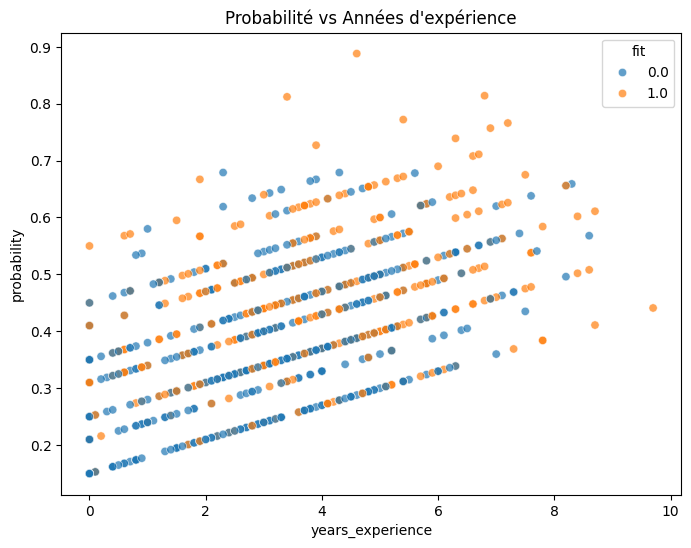

In [267]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="years_experience", y="probability", hue="fit", data=df, alpha=0.7)
plt.title("Probabilité vs Années d'expérience")
plt.show()


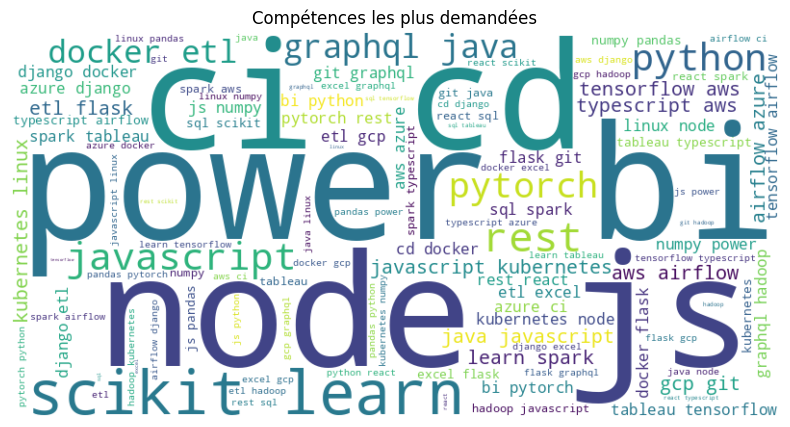

In [268]:
from wordcloud import WordCloud

all_skills = " ".join(df["required_skills"].dropna().tolist())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_skills)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Compétences les plus demandées")
plt.show()


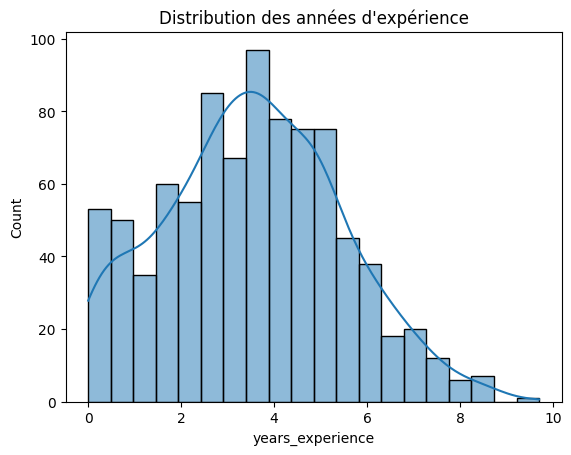

In [269]:
sns.histplot(df["years_experience"], kde=True, bins=20)
plt.title("Distribution des années d'expérience")
plt.show()


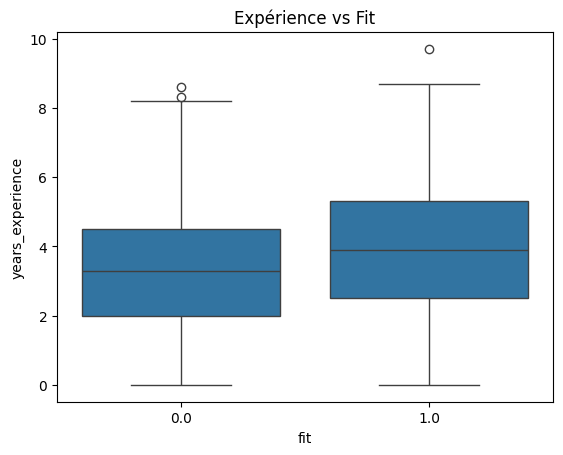

In [270]:
sns.boxplot(x="fit", y="years_experience", data=df)
plt.title("Expérience vs Fit")
plt.show()


/tmp/ipython-input-3122441292.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_skills.values()), y=list(top_skills.keys()), palette="viridis")


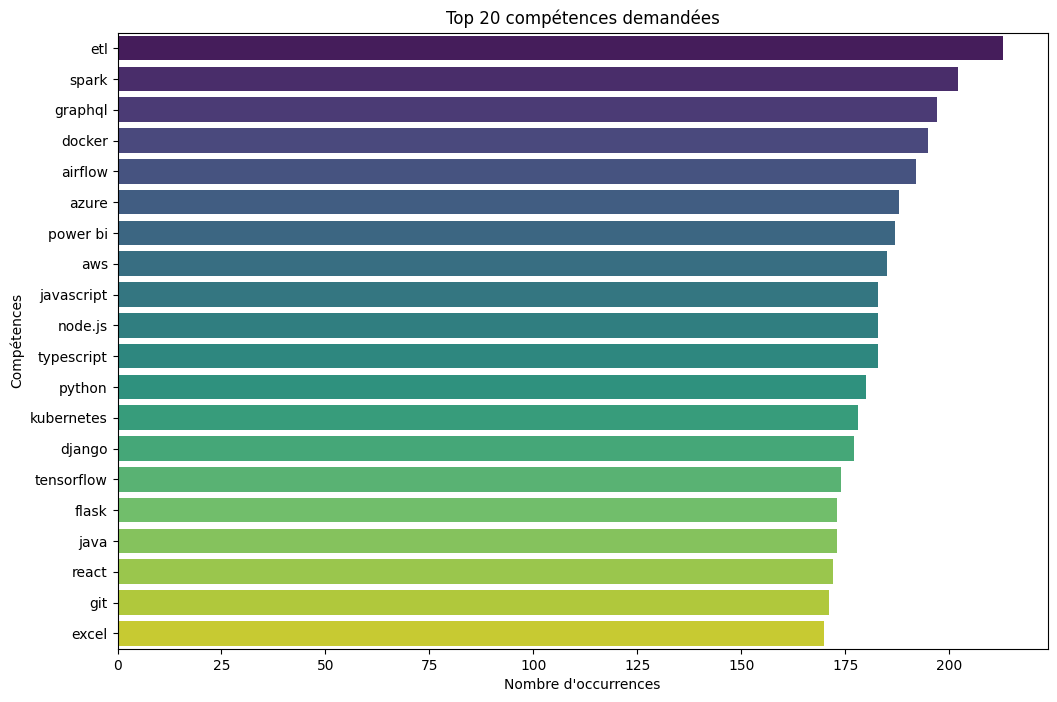

In [273]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Compter les compétences
skills = ",".join(df["required_skills"].dropna()).split(",")
skills_count = Counter([s.strip().lower() for s in skills])
top_skills = dict(skills_count.most_common(20))

# Bar chart horizontal
plt.figure(figsize=(12,8))
sns.barplot(x=list(top_skills.values()), y=list(top_skills.keys()), palette="viridis")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Compétences")
plt.title("Top 20 compétences demandées")
plt.show()


# Model

In [212]:
all_skills = df["required_skills"].tolist() + df["candidate_skills"].tolist()+ df["missing_skills"].tolist()
tfidf = TfidfVectorizer(tokenizer=lambda x: x.split(","))
tfidf.fit(all_skills)

X_req_aligned = tfidf.transform(df["required_skills"])
X_cand_aligned = tfidf.transform(df["candidate_skills"])
X_missing_skills= tfidf.transform(df["missing_skills"])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [213]:
import pandas as pd

# Pour required_skills
df_req_tfidf = pd.DataFrame(
    X_req_aligned.toarray(),
    columns=tfidf.get_feature_names_out()
)
# Pour candidate_skills
df_cand_tfidf = pd.DataFrame(
    X_cand_aligned.toarray(),
    columns=tfidf.get_feature_names_out()
)
# Pour missing_skills
df_missing_tfidf = pd.DataFrame(
    X_missing_skills.toarray(),
    columns=tfidf.get_feature_names_out()
)


In [214]:
df_req_tfidf = df_req_tfidf.add_prefix("req_")
df_cand_tfidf = df_cand_tfidf.add_prefix("cand_")
df_missing_tfidf = df_missing_tfidf.add_prefix("miss_")


In [216]:
df_req_tfidf.index = df.index
df_cand_tfidf.index = df.index
df_missing_tfidf.index = df.index

# Puis concaténer
df_final = pd.concat([df, df_req_tfidf, df_cand_tfidf, df_missing_tfidf], axis=1)


In [217]:
df_final.isnull().sum()

,0
required_skills,0
candidate_skills,0
degree,2
years_experience,0
overlap,0
...,...
miss_pytorch,0
miss_react,0
miss_rest,0
miss_scikit-learn,0


In [218]:
df_final=df_final.dropna(subset="degree")

In [219]:
df_final.isnull().sum()

,0
required_skills,0
candidate_skills,0
degree,0
years_experience,0
overlap,0
...,...
miss_pytorch,0
miss_react,0
miss_rest,0
miss_scikit-learn,0


In [220]:
df_final.head()

,required_skills,candidate_skills,degree,years_experience,overlap,fit,probability,missing_skills,req_ airflow,req_ azure,...,miss_node.js,miss_numpy,miss_pandas,miss_power bi,miss_python,miss_pytorch,miss_react,miss_rest,miss_scikit-learn,miss_sql
0,"docker, excel, linux, r, rest, tensorflow","aws, airflow, etl, hadoop, typescript",2.0,0.9,0.0,0.0,0.237,"docker, excel, linux, r, rest, tensorflow",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,"ci/cd, docker, flask, javascript, kubernetes, ...","kubernetes, numpy, python, spark",2.0,1.9,2.0,1.0,0.467,"ci/cd, docker, flask, javascript, node.js, react",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,"django, node.js, pytorch, react, sql, tensorflow","django, git, kubernetes, node.js, numpy, react...",2.0,2.5,3.0,1.0,0.585,"pytorch, sql, tensorflow",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.894804,0.0,0.0,0.0,0.0
3,"docker, etl, flask, python, rest, tensorflow, ...","aws, excel, hadoop, pytorch, r",1.0,2.7,0.0,0.0,0.231,"docker, etl, flask, python, rest, tensorflow, ...",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,"airflow, docker, kubernetes, pandas, r","docker, graphql, pytorch, rest, sql",1.0,4.9,1.0,1.0,0.397,"airflow, kubernetes, pandas, r",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [221]:
df_final.columns

Index(['required_skills', 'candidate_skills', 'degree', 'years_experience',
       'overlap', 'fit', 'probability', 'missing_skills', 'req_ airflow',
       'req_ azure',
       ...
       'miss_node.js', 'miss_numpy', 'miss_pandas', 'miss_power bi',
       'miss_python', 'miss_pytorch', 'miss_react', 'miss_rest',
       'miss_scikit-learn', 'miss_sql'],
      dtype='object', length=182)

In [222]:
df = df_final.drop(columns=["required_skills","candidate_skills","missing_skills"])


In [223]:
df.head()

,degree,years_experience,overlap,fit,probability,req_ airflow,req_ azure,req_ ci/cd,req_ django,req_ docker,...,miss_node.js,miss_numpy,miss_pandas,miss_power bi,miss_python,miss_pytorch,miss_react,miss_rest,miss_scikit-learn,miss_sql
0,2.0,0.9,0.0,0.0,0.237,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,2.0,1.9,2.0,1.0,0.467,0.0,0.0,0.0,0.0,0.376336,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,2.0,2.5,3.0,1.0,0.585,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.894804,0.0,0.0,0.0,0.0
3,1.0,2.7,0.0,0.0,0.231,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,1.0,4.9,1.0,1.0,0.397,0.0,0.0,0.0,0.0,0.487623,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [224]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Cible
X = df.drop(columns=["fit"])
y = df["fit"]

# Features : toutes les colonnes sauf 'fit'


# Transformer en float (nécessaire si certaines colonnes sont bool ou object)
X = X.astype(float)


In [225]:
y.isnull().sum()

np.int64(0)

In [226]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [227]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [228]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [229]:
X.isnull().sum()

,0
degree,0
years_experience,0
overlap,0
probability,0
req_ airflow,0
...,...
miss_pytorch,0
miss_react,0
miss_rest,0
miss_scikit-learn,0


In [230]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


Accuracy: 0.5428571428571428
Confusion Matrix:
 [[67 38]
 [42 28]]
              precision    recall  f1-score   support

         0.0       0.61      0.64      0.63       105
         1.0       0.42      0.40      0.41        70

    accuracy                           0.54       175
   macro avg       0.52      0.52      0.52       175
weighted avg       0.54      0.54      0.54       175

ROC AUC: 0.5006802721088436


In [278]:
import pickle

# Sauvegarder le modèle
with open("job_fit_Prediction.pkl", "wb") as f:
    pickle.dump(model, f)

print(" Modèle sauvegardé dans logreg_model.pkl")

 Modèle sauvegardé dans logreg_model.pkl


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.5810055865921788
Confusion Matrix:
 [[68 38]
 [37 36]]
              precision    recall  f1-score   support

       False       0.65      0.64      0.64       106
        True       0.49      0.49      0.49        73

    accuracy                           0.58       179
   macro avg       0.57      0.57      0.57       179
weighted avg       0.58      0.58      0.58       179

ROC AUC: 0.5535021969501163


In [279]:
df.to_csv("job_fit_clean_data.csv", index=False)